# Virtual Point Transformation
Transformations can be useful in noise and vibration applications, such as: multiple-input/multiple-output (MIMO) vibration testing [@Rohe2021], substructuring [@VanDerSeijs2013], and transfer path analysis. This example will derive the basic theory for how transformations are applied in SDynPy. It will also demonstrate how some standard functions can be used to perform a virtual point transformation based on rigid body kinematics. It will show how to generate an example problem, create the transformation matrices, then apply the transformations to different data types. 

## Importing the Required Packages

In [1]:
import numpy as np
import sdynpy as sdpy
from scipy.signal import chirp

## Basic Transformation Theory
This section derives the equations for how transformation are applied to time traces, frequency spectra, cross-power spectral densities (CPSDs), and frequency response functions (FRFs) in SDynPy. The starting point for the derivation is the basic response transformation, where physical responses are turned into transformed responses. This transformation is shown in the equation below, where $\left\{x\right\}$ is a vector of physical responses (in the time or frequency domain), $\left[T\right]$ is the transformation matrix, and $\left\{\hat{x}\right\}$ is a vector of transformed responses.

\begin{equation}
\left\{\hat{x}\right\}=\left[T\right]\left\{x\right\}
\end{equation}

This transformation framework can easily be applied to CPSD matrices through the following equations, where $\left[{\hat{G}}_ {xx}\right]$ is transformed response CPSD matrix, $\left[G_ {xx}\right]$ is the physical response CPSD matrix, and $\left[\bullet\right]^\ast$ indicates the conjugate-transpose of the given matrix or vector. 

\begin{equation}
\left[{\hat{G}}_{xx}\right]=\left\{\hat{x}\right\}\left\{\hat{x}\right\}^\ast=\left(\left[T\right]\left\{x\right\}\right)\left(\left[T\right]\left\{x\right\}\right)^\ast=\left[T\right]\left\{x\right\}\left\{x\right\}^\ast\left[T\right]^\ast=\left[T\right]\left[G_{xx}\right]\left[T\right]^\ast
\end{equation}

The response transformation is applied to FRFs by substituting the FRF equation of motion into the original response transformation that was shown above. In this equation, $\left[H\right]$ is a matrix of FRFs and $\left\{f\right\}$ is a vector of forces.  

\begin{equation}
\left\{\hat{x}\right\}=\left[T_ {response}\right]\left\{x\right\}=\left[T_ {response}\right]\left[H\right]\left\{f\right\}
\end{equation}

A force (more generically called a reference) transformation can also be applied to the FRFs through the following operations. First, the force transformation equation is written to convert the physical forces into transformed forces. 

\begin{equation}
\left\{\hat{f}\right\}=\left[T_ {force}\right]\left\{f\right\}
\end{equation}

Next, the force transformation equation is inverted to convert the transformed forces into physical forces, where $\left[\bullet\right]^\dag$ indicates a pseudo-inverse of the given matrix. 

\begin{equation}
\left\{f\right\}=\left[T_ {force}\right]^\dag\left\{\hat{f}\right\}
\end{equation}

Finally, the inverted force transformation equation is then plugged into the FRF equation of motion.

\begin{equation}
\left\{x\right\}=\left[H\right]\left\{f\right\}=\left[H\right]\left[T_ {force}\right]^\dag\left\{\hat{f}\right\}
\end{equation}

Both the force and response transformations can be applied to the FRFs in the same operation to calculate the transformed FRFs, denoted by $\left[\hat{H}\right]$.

\begin{equation}
\left[\hat{H}\right]=\left[T_ {response}\right]\left[H\right]\left[T_ {force}\right]^\dag
\end{equation}

### Convention for Transformations in SDynPy
The SDynPy functions for transformations assume that the user is supplying transformations in a format that converts physical quantities to the transformed quantities. However, this convention does not represent all the use cases. For example, one might need to convert the transformed quantity back to the physical quantity, or it might be easier to compute the inverted transformation matrix (that converts the transformed quantity to the physical quantity). Consequently, options are available in all the transformation functions to invert the supplied transformations, so they are compatible with whatever transformation convention is being used. 

## Generating the Example Problem
The example system is a two dimensional beam (only in-plane motion) that is rigidly coupled to a node through a rigid spider via static condensation (similar to an rbe2 element). The red portion of the image is the beam where each circle is a node on the beam, the green circle is the node that is external to the beam (referred to as the external node), and the blue lines are the rigid spider that connects the beam and external node. Each node in the system allows for X, Z, and RY motion, as shown in the picture. 


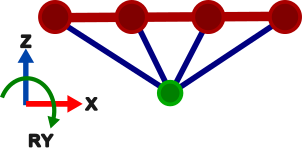

### Creating the Beam Mass and Stiffness Matrices
The mass and stiffness matrices will be defined for the beam using standard SDynPy functions for Euler-Bernoulli beams with the supplied material properties

In [2]:
beam_length = 1 # m
box_cross_section_size = 0.05 # m
number_nodes = 4

youngs_modulus = 69.8e9 # pa
density = 2700 # kg/m^3
poissons_ratio = 0.33

beam_k, beam_m = sdpy.beam.beamkm_2d(beam_length, box_cross_section_size, box_cross_section_size, 
                                     number_nodes, youngs_modulus, density, poissons_ratio)

### Generating the External Node Mass and Stiffness Matrices
The mass and stiffness for the different degrees of freedom (DOFs) in the external node are uncoupled from each other, so there will only be entries on the diagonal of the accompanying matrices. 

In [3]:
external_node_m = np.zeros((3, 3), dtype=float)
external_node_m[0,0] = 0.01 # kg
external_node_m[1,1] = 0.01 # kg
external_node_m[2,2] = 0.01 # kg*m^2

external_node_k = np.zeros((3, 3), dtype=float)
external_node_k[0,0] = 10e6 # kg
external_node_k[1,1] = 10e6 # kg
external_node_k[2,2] = 10e3 # N*m/rad

### Assembling the System Mass and Stiffness Matrices
The uncoupled mass and stiffness matrices for the system will be assembled in block diagonal fashion with the external node being in the upper left block of the system matrices. 

In [4]:
physical_m = np.zeros((beam_m.shape[0]+external_node_m.shape[0], beam_m.shape[1]+external_node_m.shape[1]), dtype=float)
physical_m[:3, :3] = external_node_m
physical_m[3:, 3:] = beam_m

physical_k = np.zeros((beam_k.shape[0]+3, beam_k.shape[1]+3), dtype=float)
physical_k[:3, :3] = external_node_k
physical_k[3:, 3:] = beam_k

### Creating the System Geometry
A SDynPy `Geometry` object will be manually created for the system. This geometry will be used later in the demonstration to create the kinematic transformation. 

In [5]:
node_locations = np.array([[ 0,     0, 0],
                           [-0.5,   0, 0.1],
                           [-0.165, 0, 0.1],
                           [ 0.165, 0, 0.1],
                           [ 0.5,   0, 0.1]])

node_array = sdpy.node_array([101,201,202,203,204], node_locations)

traceline_array = sdpy.traceline_array(id=1, connectivity=[201,202,203,204,0,101,201,0,101,202,0,101,203,0,101,204])

system_geometry = sdpy.Geometry(node_array, sdpy.coordinate_system_array(id=1), traceline_array)

In [6]:
system_geometry.plot();

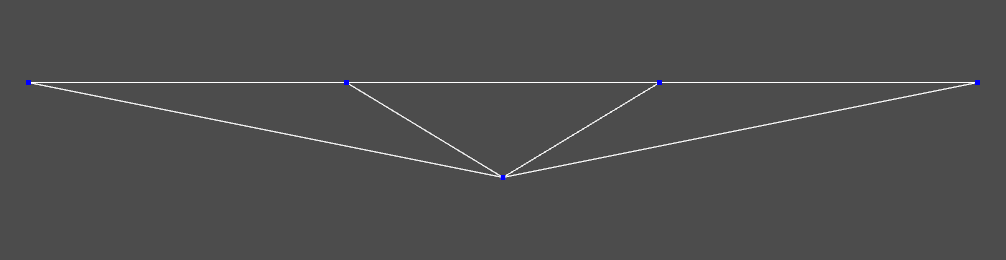

### Making the Transformed System Object
The external node and beam will be coupled to one another via static condensation with a transformation matrix that is applied to both the mass and stiffness matrices. A damping matrix matrix will also be created for the system via some proportional factors from the transformed mass and stiffness matrices (the precise level of damping is inconsequential for this exercise). These transformed mass, stiffness, and damping matrices along with the transformation matrix will then be compiled into a SDynPy system object that can be used to compute time responses or FRFs for the system. 

In [7]:
transformation_array = np.array([[1, 0, 0, 1,   0,   0, 1,   0,     0, 1,    0,     0, 1,    0,   0], 
                                 [0, 1, 0, 0,   1,   0, 0,   1,     0, 0,    1,     0, 0,    1,   0], 
                                 [0, 0, 1, 0.1, 0.5, 0, 0.1, 0.165, 0, 0.1, -0.165, 0, 0.1, -0.5, 0]])

transformed_m = transformation_array@physical_m@transformation_array.T
transformed_k = transformation_array@physical_k@transformation_array.T
transformed_c = 0.0001*transformed_m + 0.00001*transformed_k

system_coordinate = sdpy.coordinate_array(node=np.array([101,201,202,203,204])[...,np.newaxis], direction=[1,3,5]).flatten()
transformed_system = sdpy.System(system_coordinate, transformed_m, transformed_k, transformed_c, transformation=transformation_array.T)

The mode shapes can be computed and reviewed to verify that the system behaves like a rigid body. 

In [8]:
transformed_shapes = transformed_system.eigensolution()
system_geometry.plot_shape(transformed_shapes);

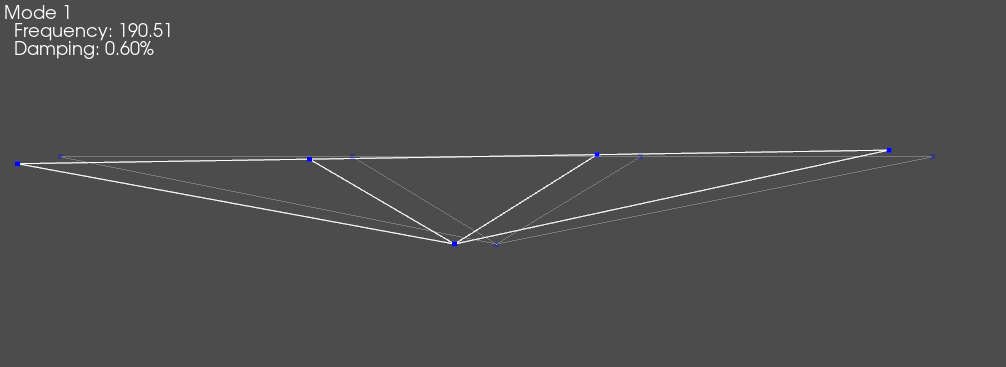

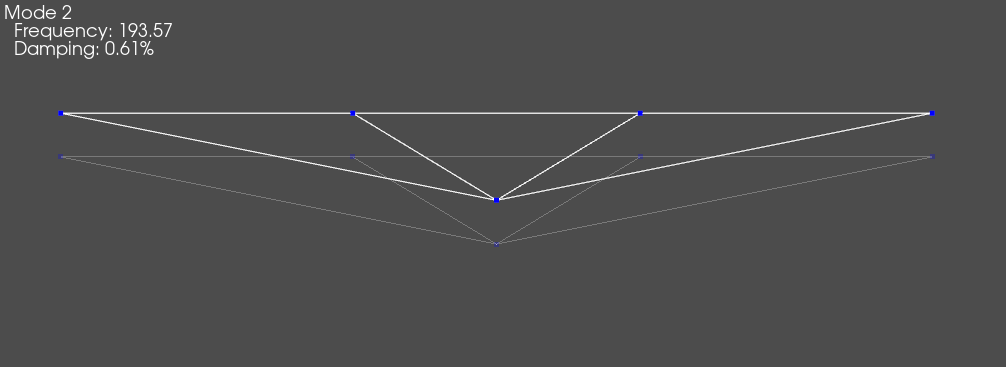

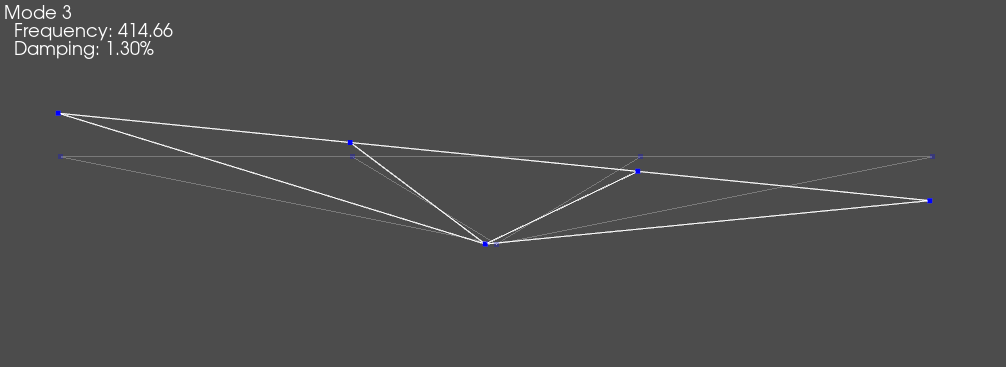

## Performing Response Transformations
The response transformations will be demonstrated using the example system with the following process:

1. Time integration will be used to compute the response of the example system to a supplied force. 
2. A rigid kinematic transformation will be created from the system geometry to transform the beam motion to the external node motion.
3. The "truth" external node motion from the time integration will be compared to the transformed motion from step two to demonstrate that the virtual point transformation worked as expected.

The above process will be repeated for a SDynPy `TimeHistoryArray`, `SpectrumArray`, and `PowerSpectralDensityArray`. Note that the core aspects of the demonstration will be done using pre-made SDynPy functions and methods, meaning that minimal coding is required to perform transformations. 

### Compute the Time Response
The `time_integration` method for the SDynPy system object is used to compute the response of the previously created `transformed_system` to a supplied force. In this case, chirp excitation will be applied to the external node. Note that the excitation bandwidth encompasses the modes of the system. Otherwise, the precise details of the excitation are inconsequential for this demonstration.   

In [9]:
time = np.arange(5001)/5000

external_node_coordinate = sdpy.coordinate_array(node=101, direction=[1,3,5]).flatten()

chirp_excitation_ordinate = np.array([chirp(time, 20, 1, 500), chirp(time, 20, 1, 500), chirp(time, 20, 1, 500)])

chirp_excitation = sdpy.data_array(sdpy.data.FunctionTypes.TIME_RESPONSE, time, chirp_excitation_ordinate, external_node_coordinate[...,np.newaxis])
time_response = transformed_system.time_integrate(chirp_excitation,{2:transformed_system.coordinate})

### Creating the Response Transformation Matrix
The response transformation is created by using the "response_kinematic_transformation" method for the SDynPy geometry object. In this case, the "beam_transform_coordinate" defines the DOFs on the beam that will be transformed to the external node. Note that the one and three directions correspond to the X and Z direction, meaning that only translation beam motion will be used to recreate the 3DOF (X, Z, RY) external node motion. 

In [10]:
beam_transform_coordinate = sdpy.coordinate_array(node=np.array([201,202,203,204])[...,np.newaxis], direction=[1,3]).flatten()
response_transformation = system_geometry.response_kinematic_transformation(response_coordinate = beam_transform_coordinate, 
                                                                            virtual_point_node_number = 101,
                                                                            virtual_point_location = node_array[node_array.id==101].coordinate[0,...])

### Apply the Transformation to the Response Data
The response transformation is applied to the response data using the `apply_transformation` method that has been implemented for the `TimeHistoryArray`, `SpectrumArray`, and `PowerSpectralDensityArray` response types in SDynPy. The accuracy of the transformed response can be verified by comparing it to  the "truth" response at the external node of the system via a NumPy `allclose` comparison (where the comparison should result in `True`). Note that imperfections in floating point arithmetic mean that the transformed response will never match the truth response via an `==` comparison, which is why `allclose` is being used. 

Also note that different `CoordinateArray` objects are being used to index the response data to ensure the correct data is being used at each step in the analysis. 

#### TimeHistoryArray

In [11]:
transformed_time_response = time_response[beam_transform_coordinate[...,np.newaxis]].apply_transformation(response_transformation)

if np.allclose(transformed_time_response[external_node_coordinate[...,np.newaxis]].ordinate, time_response[external_node_coordinate[...,np.newaxis]].ordinate):
    print('The transformed and truth time responses match')
else:
    print('The transformation did not work as expected')

The transformed and truth time responses match


#### SpectrumArray
The time response is converted to a spectrum using the `fft` method for TimeHistoryArrays. This method returns the raw discrete Fourier transform of the time trace, meaning that no windowing or averaging parameters are supplied. 

In [12]:
spectrum_response = time_response.fft()

transformed_spectrum_response = spectrum_response[beam_transform_coordinate[...,np.newaxis]].apply_transformation(response_transformation)

if np.allclose(transformed_spectrum_response[external_node_coordinate[...,np.newaxis]].ordinate, spectrum_response[external_node_coordinate[...,np.newaxis]].ordinate):
    print('The transformed and truth spectrum responses match')
else:
    print('The transformation did not work as expected')

The transformed and truth spectrum responses match


#### PowerSpectralDensityArray
The time response is converted to a CPSD using the `cpsd` method for TimeHistoryArrays. In this case a single average is used with no overlap or windowing. Note that the `apply_transformation` method for PowerSpectralDensityArrays is limited to "full" CPSD arrays, meaning that CPSD array must have the power spectral densities and cross terms. 

In [13]:
cpsd_response = time_response.cpsd(samples_per_frame=time.shape[0], overlap=0, window='boxcar')

transformed_cpsd_response = cpsd_response[sdpy.coordinate.outer_product(beam_transform_coordinate, beam_transform_coordinate)].apply_transformation(response_transformation)

external_node_cpsd_coordinate = sdpy.coordinate.outer_product(external_node_coordinate, external_node_coordinate)
if np.allclose(transformed_cpsd_response[external_node_cpsd_coordinate].ordinate, cpsd_response[external_node_cpsd_coordinate].ordinate):
    print('The transformed and truth CPSD responses match')
else:
    print('The transformation did not work as expected')

The transformed and truth CPSD responses match


## Performing FRF Transformations
Transformations can be applied to FRFs in a similar manner to how the response transformations were done. The FRFs will be computed using the `frequency_response` method for the SDynPy system object for this example. CoordinateArray indexing will then be used to separate the different groups of FRFs for the transformations and comparison steps in the analysis. Note that the frequency range for the FRFs was selected such that it encompassed all the modes of the system.

In [14]:
frequency = np.arange(601)
system_frf = transformed_system.frequency_response(frequency, system_coordinate, system_coordinate)

external_node_frf = system_frf[external_node_cpsd_coordinate]
beam_frf = system_frf[sdpy.coordinate.outer_product(beam_transform_coordinate, beam_transform_coordinate)]

The virtual point transformation for this demonstration requires both a reference and response transformation. The response transformation that was previously created can be applied to the FRFs, but a separate reference transformation must be created. In this case, the reference transformation is created using the `force_kinematic_transformation` method for `Geometry` objects. Note that this method is being used since force transformations are defined slightly differently than response transformations, more details can be found in [@VanDerSeijs2013]. Similar to the response transformation, the reference transformation will only translation beam excitation to recreate the 3DOF (X, Z, RY) external node excitation. 

In [15]:
reference_transformation = system_geometry.force_kinematic_transformation(force_coordinate = beam_transform_coordinate, 
                                                                          virtual_point_node_number = 101,
                                                                          virtual_point_location = node_array[node_array.id==101].coordinate[0,...])

The transformations are applied to the FRFs using the `apply_transformation` method for `TransferFunctionArrays`. It should be noted that the other applications (such as a MIMO vibration test) may not need both a response and reference transformation. As such, the apply_transformation method does not require that both a response and reference transformation be supplied (i.e., the user can supply either transformation on its own). 

In [16]:
transformed_frf = beam_frf.apply_transformation(response_transformation = response_transformation, 
                                                reference_transformation = reference_transformation)[external_node_cpsd_coordinate]

The transformed and truth FRFs are compared with a NumPy `allclose` comparison to verify that the virtual point transformation worked as expected. In this case, some DOFs in system are not coupled to one another, meaning that the cross-FRFs will have an amplitude that is less than machine precision. As such, only the driving point FRFs are being compared. 

In [17]:
if np.allclose(external_node_frf.ordinate.diagonal(axis1=0, axis2=1), transformed_frf.ordinate.diagonal(axis1=0, axis2=1)):
    print('The transformed and truth FRFs match')
else:
    print('The transformation did not work as expected')

The transformed and truth FRFs match


## Summary
This example introduced the basic theory for transformations, as they are applied in SDynPy. It then developed an example system to demonstrate how the transformation methods can be easily applied to `TimeHistoryArray`s, `SpectrumArray`s, `PowerSpectralDensityArray`s, and `TransferFunctionArray`s. Note that while this example only demonstrated the application of rigid kinematic transformations, more exotic transformations [@Haeussler2017] [@Schultz2020] [@Trainotti2022] could also be used with the `apply_transformation` method.